Successfully loaded the dataset. Row count: 1000
Grand Total Spending analyzed: $1,795,083.00


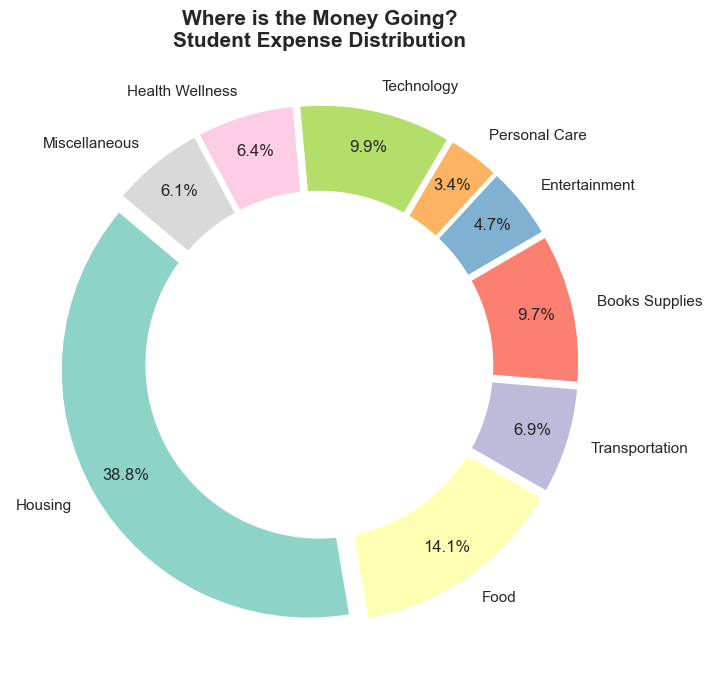

C:\Users\User\AppData\Local\Temp\ipykernel_16296\3552642617.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


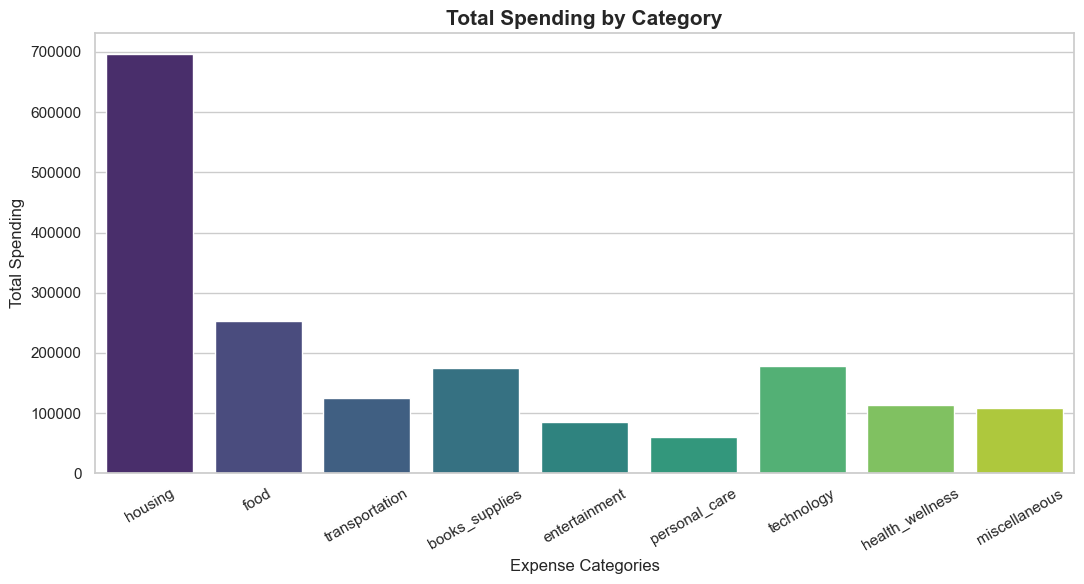

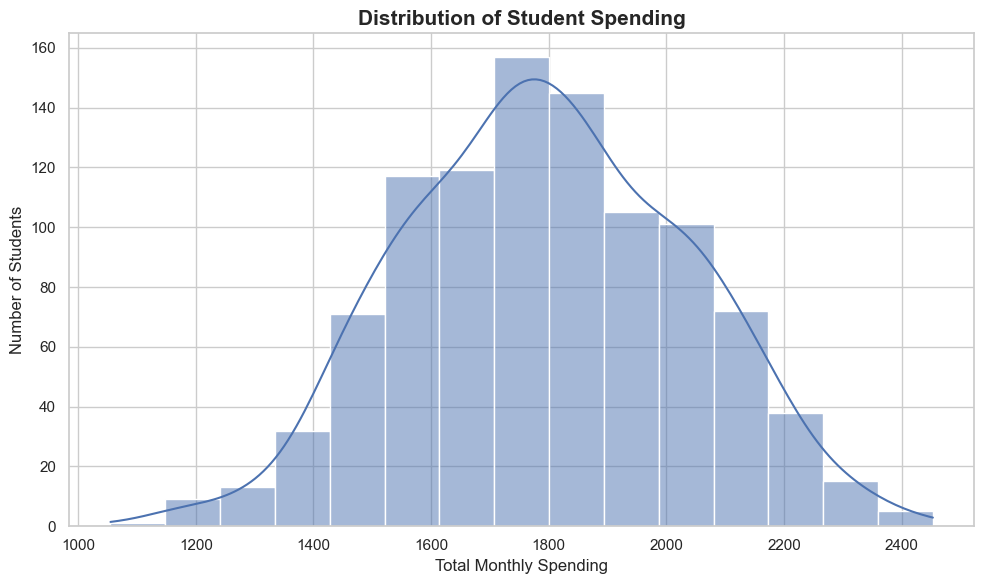

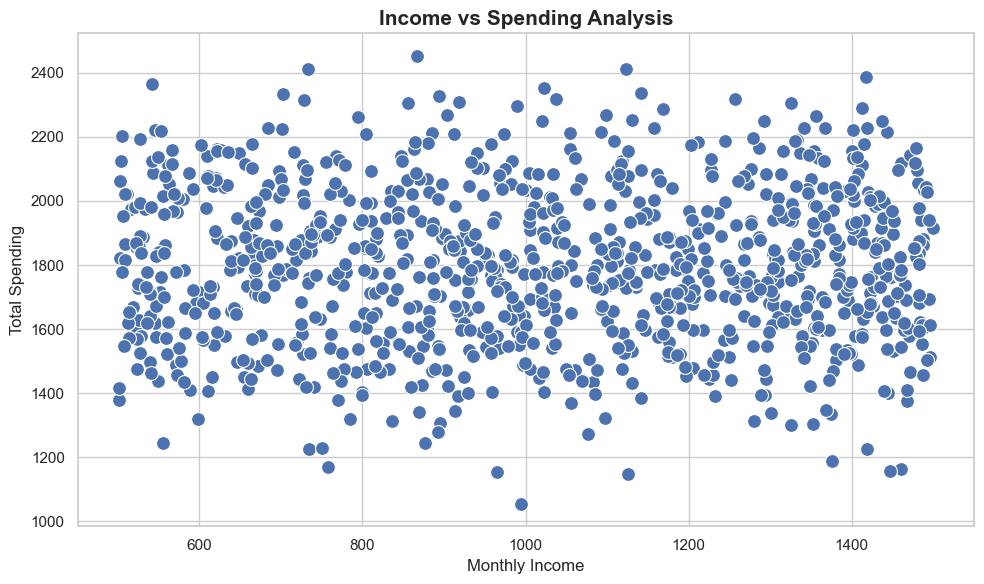


FINANCIAL INSIGHTS REPORT

1. MAJOR COST: HOUSING is the largest expense for students.
2. BUDGET RATIO: Students spend 175.9% of their monthly income on average.
3. PRIORITIES: Students spend $1,123,409 on Essentials vs $254,423 on Lifestyle.
4. WARNING: On average, students are overspending their income by $774.43.


In [ ]:
# Project:     Student Personal Expense Analysis
# Created by:  Abdullah Zia     2024-ag-4523
#              Muhammad Arslan  2024-ag-9722
#              Akif Sajjad      2024-ag-9115
# Date:        May 2026


# Importing libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Loading dataset
try:
    data = pd.read_csv('student_spending.csv')

    if data.columns[0].startswith('Unnamed'):
        data.drop(data.columns[0], axis=1, inplace=True)

    print("Successfully loaded the dataset. Row count:", len(data))

except Exception as e:
    print(f"Check your file name! Error: {e}")

# Expense categories
categories = [
    'housing', 'food', 'transportation', 'books_supplies',
    'entertainment', 'personal_care', 'technology',
    'health_wellness', 'miscellaneous'
]

# Totals and calculations
category_totals = data[categories].sum()
data['total_spent'] = data[categories].sum(axis=1)

avg_income = data['monthly_income'].mean()
avg_spend = data['total_spent'].mean()
total_spending = category_totals.sum()

print(f"Grand Total Spending analyzed: ${total_spending:,.2f}")

# Pie chart

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 7))

plt.pie(
    category_totals,
    labels=[c.replace('_', ' ').title() for c in categories],
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette("Set3"),
    pctdistance=0.85,
    explode=[0.05] * len(categories)
)

plt.gca().add_artist(plt.Circle((0, 0), 0.70, fc='white'))

plt.title(
    "Where is the Money Going?\nStudent Expense Distribution",
    fontsize=15,
    fontweight='bold'
)

plt.tight_layout()
plt.savefig('expense_pie_chart.png', dpi=300)
plt.show()

# bar graph

plt.figure(figsize=(11, 6))

sns.barplot(
    x=category_totals.index,
    y=category_totals.values,
    palette="viridis"
)

plt.xticks(rotation=30)
plt.xlabel("Expense Categories")
plt.ylabel("Total Spending")
plt.title(
    "Total Spending by Category",
    fontsize=15,
    fontweight='bold'
)

plt.tight_layout()
plt.savefig('expense_bar_chart.png', dpi=300)
plt.show()

# histogram

plt.figure(figsize=(10, 6))

sns.histplot(
    data['total_spent'],
    bins=15,
    kde=True
)

plt.xlabel("Total Monthly Spending")
plt.ylabel("Number of Students")
plt.title(
    "Distribution of Student Spending",
    fontsize=15,
    fontweight='bold'
)

plt.tight_layout()
plt.savefig('expense_histogram.png', dpi=300)
plt.show()

# scatter plot

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=data['monthly_income'],
    y=data['total_spent'],
    s=100
)

plt.xlabel("Monthly Income")
plt.ylabel("Total Spending")
plt.title(
    "Income vs Spending Analysis",
    fontsize=15,
    fontweight='bold'
)

plt.tight_layout()
plt.savefig('income_vs_spending.png', dpi=300)
plt.show()

# Insights

print("\nFINANCIAL INSIGHTS REPORT\n")

top_cat = category_totals.idxmax()

print(f"1. MAJOR COST: {top_cat.upper()} is the largest expense for students.")

ratio = (avg_spend / avg_income) * 100

print(f"2. BUDGET RATIO: Students spend {ratio:.1f}% of their monthly income on average.")

essentials = (
    category_totals['housing']
    + category_totals['food']
    + category_totals['books_supplies']
)

lifestyle = (
    category_totals['entertainment']
    + category_totals['personal_care']
    + category_totals['miscellaneous']
)

print(f"3. PRIORITIES: Students spend ${essentials:,.0f} on Essentials vs ${lifestyle:,.0f} on Lifestyle.")

savings = avg_income - avg_spend

if savings > 0:
    print(f"4. SAVINGS: On average, students have a surplus of ${savings:.2f} per month.")
else:
    print(f"4. WARNING: On average, students are overspending their income by ${abs(savings):.2f}.")